In [ ]:
from preprocessing.file_conversion import file_conversion
import numpy as np
import pandas as pd
from features import feature_extraction
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import seaborn as sns 
#path = "/Users/reymendoza/Desktop/sleep_files"
#X, y, groups = file_conversion(path)

#np.savez_compressed("sleep_dataset.npz", X=X, y=y, groups=groups)

data = np.load("/Users/reymendoza/Developer/Sleep-Stage-Classification/preprocessing/sleep_dataset.npz", allow_pickle=True)
X = data["X"]
y = data["y"]
groups = data["groups"]

In [51]:
feature_df = feature_extraction(X)
feature_df['label'] = y
feature_df['label'] = feature_df['label'].replace({1: 'Awake', 2: 'REM', 3: 'N1', 4: 'N2', 5: 'N3'})
feature_df['group'] = groups
feature_df = feature_df.dropna()

In [52]:
feature_df

,delta_abs_bandpower,theta_abs_bandpower,alpha_abs_bandpower,beta_abs_bandpower,gamma_abs_bandpower,delta_rel_bandpower,theta_rel_bandpower,alpha_rel_bandpower,beta_rel_bandpower,gamma_rel_bandpower,...,delta_alpha_ratio,theta_alpha_ratio,delta_beta_ratio,alpha_beta_ratio,hjorth_activity,hjorth_mobility,hjorth_complexity,spectral_entropy,label,group
0,-9.340358,-9.910352,-10.127414,-10.097334,-10.590217,0.602932,0.161317,0.097342,0.104418,0.032668,...,0.786103,0.213514,0.756023,-0.035943,1.268570e-09,0.213001,3.973660,6.677247,Awake,sub-001
1,-9.692165,-10.223911,-10.348477,-10.381935,-10.891655,0.564634,0.163995,0.122405,0.113122,0.033051,...,0.654169,0.117231,0.687627,0.023660,4.379164e-09,0.167247,5.872854,6.135448,Awake,sub-001
2,-9.632274,-9.985766,-10.359309,-10.192977,-10.738928,0.506301,0.223131,0.093152,0.137640,0.037596,...,0.725169,0.369319,0.558837,-0.176380,1.334319e-09,0.217025,4.118894,7.015822,Awake,sub-001
3,-9.776617,-10.091223,-10.311116,-10.243820,-10.700903,0.449203,0.216297,0.129290,0.151413,0.051095,...,0.531895,0.214501,0.464599,-0.076278,1.336577e-09,0.219342,3.961222,6.082853,Awake,sub-001
4,-8.951274,-7.830402,-8.681631,-8.971276,-9.658440,0.058029,0.767145,0.108011,0.055415,0.011347,...,-0.270031,0.851199,0.019614,0.289436,1.239783e-07,0.189165,4.968850,6.201722,Awake,sub-001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,-11.007571,-11.473884,-11.598353,-11.806439,-11.929650,0.611119,0.163267,0.105331,0.038878,0.012174,...,0.544176,-0.029052,0.752261,-0.011310,5.957145e-11,0.098884,4.276552,5.122903,REM,sub-007
6037,-11.219919,-11.363821,-11.288559,-11.781870,-11.961818,0.352909,0.233572,0.291053,0.045807,0.006452,...,-0.010156,-0.189398,0.483155,0.399464,4.628002e-11,0.117563,3.232156,5.994471,REM,sub-007
6038,-10.934197,-11.263874,-11.591654,-11.731027,-11.939862,0.570312,0.238431,0.083682,0.045990,0.007964,...,0.618432,0.239682,0.757805,-0.075674,3.710053e-11,0.143616,3.036865,6.799096,REM,sub-007
6039,-11.226461,-11.375644,-11.636703,-11.768350,-11.962730,0.438812,0.285398,0.116296,0.062641,0.007965,...,0.330132,0.143305,0.461780,-0.114934,3.968308e-10,0.049504,9.081702,4.898624,REM,sub-007


##### sub-008 appears to have all epochs with NaNs

In [19]:
feature_df.groupby("group").apply(lambda x: x.isna().any(axis=1).sum())

group
sub-001       0
sub-003       0
sub-004       0
sub-005       0
sub-006       0
sub-007       0
sub-008    1013
dtype: int64

In [20]:
feature_df['group'].value_counts()

group
sub-003    1068
sub-007    1035
sub-005    1028
sub-008    1013
sub-004    1006
sub-006     962
sub-001     942
Name: count, dtype: int64

#### __Label Distributions__
##### N2 sleep makes the majority of the sleep epochs, followed by REM, Awake, N3 (deep) sleep, and N1 sleep (the lowest proportion)

In [21]:
print(feature_df['label'].value_counts())
print(feature_df['label'].value_counts(normalize=True))

label
N2       3041
REM      1254
Awake    1111
N3        976
N1        672
Name: count, dtype: int64
label
N2       0.431103
REM      0.177771
Awake    0.157499
N3       0.138361
N1       0.095265
Name: proportion, dtype: float64


#### __Label Distributions__
##### N2 sleep makes the majority of the sleep epochs, followed by REM, Awake, N3 (deep) sleep, and N1 sleep (the lowest proportion)

In [ ]:
# Calculating feature variance to ensure no static feature
numeric_df = feature_df.select_dtypes(include=[np.number]).drop(columns=["label", "group"], errors="ignore")
numeric_df = numeric_df.dropna()

summary = pd.DataFrame({
    "mean": numeric_df.mean(),
    "std": numeric_df.std(),
    "var": numeric_df.var()
})

summary["coef_var"] = summary["std"] / summary["mean"].abs()
summary = summary.sort_values("var")

print(summary)

                             mean           std           var  coef_var
hjorth_activity      1.189814e-07  9.789803e-07  9.584025e-13  8.228012
gamma_rel_bandpower  2.649755e-02  2.335295e-02  5.453601e-04  0.881325
alpha_rel_bandpower  8.031694e-02  3.763590e-02  1.416461e-03  0.468592
beta_rel_bandpower   8.771941e-02  4.768102e-02  2.273479e-03  0.543563
theta_rel_bandpower  1.624595e-01  6.069170e-02  3.683483e-03  0.373581
hjorth_mobility      1.415998e-01  6.515888e-02  4.245679e-03  0.460162
delta_rel_bandpower  6.165431e-01  1.347487e-01  1.815721e-02  0.218555
alpha_beta_ratio    -1.329592e-01  1.704812e-01  2.906385e-02  1.282207
theta_alpha_ratio    2.145481e-01  1.879213e-01  3.531442e-02  0.875893
delta_theta_ratio    5.433419e-01  2.917919e-01  8.514250e-02  0.537032
delta_alpha_ratio    8.174968e-01  3.652496e-01  1.334073e-01  0.446790
delta_beta_ratio     8.009595e-01  3.979377e-01  1.583544e-01  0.496826
gamma_abs_bandpower -1.129717e+01  7.911295e-01  6.258859e-01  0

In [ ]:
# Discovering features that discriminate any label well
df = feature_df.copy()
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["group"], errors="ignore")
numeric_df = numeric_df.dropna()
df = df.loc[numeric_df.index].copy()

results = []

for feature in numeric_df.columns:
    groups = [
        df.loc[df["label"] == cls, feature].dropna().values
        for cls in sorted(df["label"].unique())
    ]
    
    stat, p = kruskal(*groups)
    results.append({
        "feature": feature,
        "kruskal_stat": stat,
        "p_value": p
    })

results_df = pd.DataFrame(results).sort_values("p_value")
print(results_df)

                feature  kruskal_stat        p_value
11    delta_alpha_ratio   1366.144044  1.515975e-294
10    delta_theta_ratio   1344.300951  8.257899e-290
15      hjorth_activity   1292.332197  1.529836e-278
0   delta_abs_bandpower   1160.305485  6.414394e-250
4   gamma_abs_bandpower   1110.574909  3.863865e-239
13     delta_beta_ratio   1064.340426  4.057691e-229
6   theta_rel_bandpower   1011.263028  1.293349e-217
5   delta_rel_bandpower   1007.434587  8.737901e-217
3    beta_abs_bandpower    962.439155  4.923090e-207
2   alpha_abs_bandpower    891.949357  9.245727e-192
1   theta_abs_bandpower    807.119191  2.204332e-173
17    hjorth_complexity    785.274794  1.188069e-168
12    theta_alpha_ratio    782.421566  4.929866e-168
7   alpha_rel_bandpower    716.199831  1.082425e-153
9   gamma_rel_bandpower    411.440136   9.381932e-88
8    beta_rel_bandpower    386.339736   2.486418e-82
14     alpha_beta_ratio    353.669794   2.828766e-75
16      hjorth_mobility    302.451233   3.2065

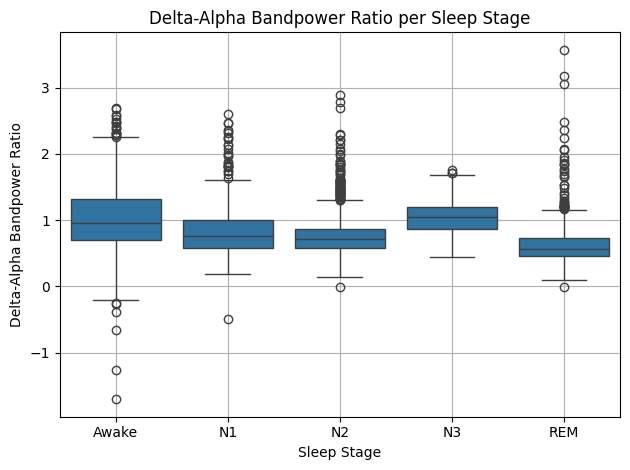

In [ ]:
# Delta-Alpha Ratio vs Sleep Stage
sns.boxplot(feature_df, x='label', y='delta_alpha_ratio')
plt.title('Delta-Alpha Bandpower Ratio per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Delta-Alpha Bandpower Ratio')
plt.grid()
plt.tight_layout()

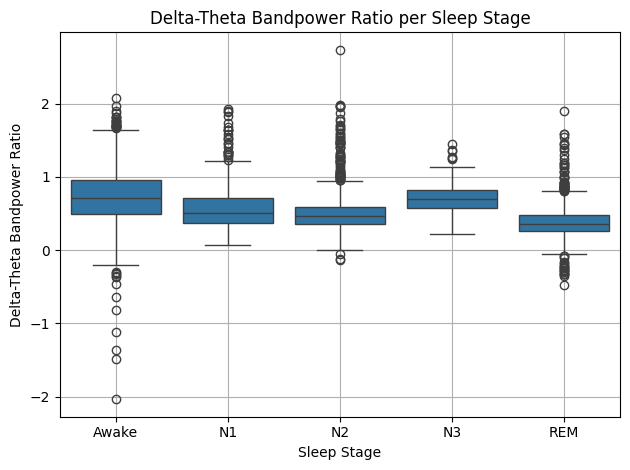

In [ ]:
# Delta-Theta Ratio vs Sleep Stage
sns.boxplot(feature_df, x='label', y='delta_theta_ratio')
plt.title('Delta-Theta Bandpower Ratio per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Delta-Theta Bandpower Ratio')
plt.grid()
plt.tight_layout()

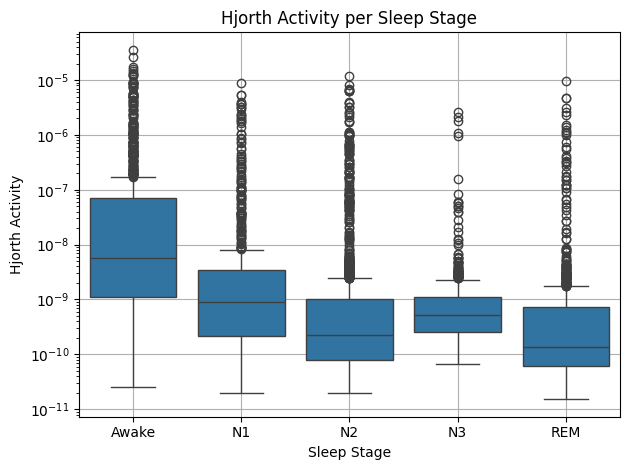

In [ ]:
# Hjorth Activity vs Sleep Stage
sns.boxplot(feature_df, x='label', y='hjorth_activity') # log scaled
plt.title('Hjorth Activity per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Hjorth Activity')
plt.yscale('log')
plt.grid()
plt.tight_layout()

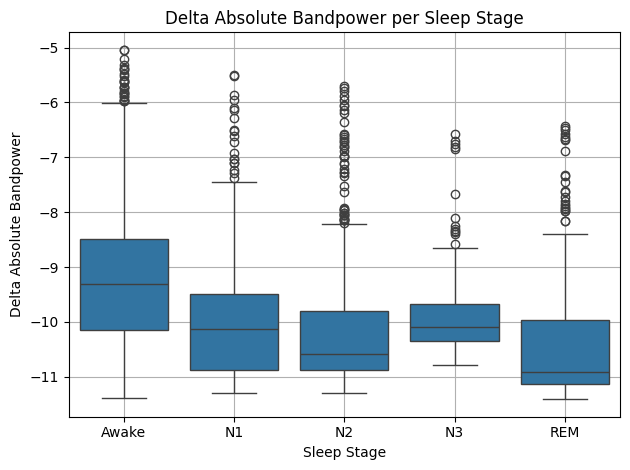

In [ ]:
# Delta Absolute Bandpower vs Sleep Stage
sns.boxplot(feature_df, x='label', y='delta_abs_bandpower')
plt.title('Delta Absolute Bandpower per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Delta Absolute Bandpower')
plt.grid()
plt.tight_layout()

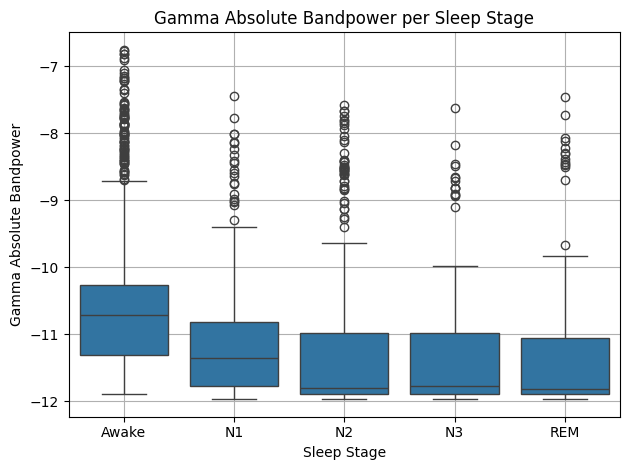

In [ ]:
# Gamma Absolute Bandpower vs Sleep Stage
sns.boxplot(feature_df, x='label', y='gamma_abs_bandpower')
plt.title('Gamma Absolute Bandpower per Sleep Stage')
plt.xlabel('Sleep Stage')
plt.ylabel('Gamma Absolute Bandpower')
plt.grid()
plt.tight_layout()

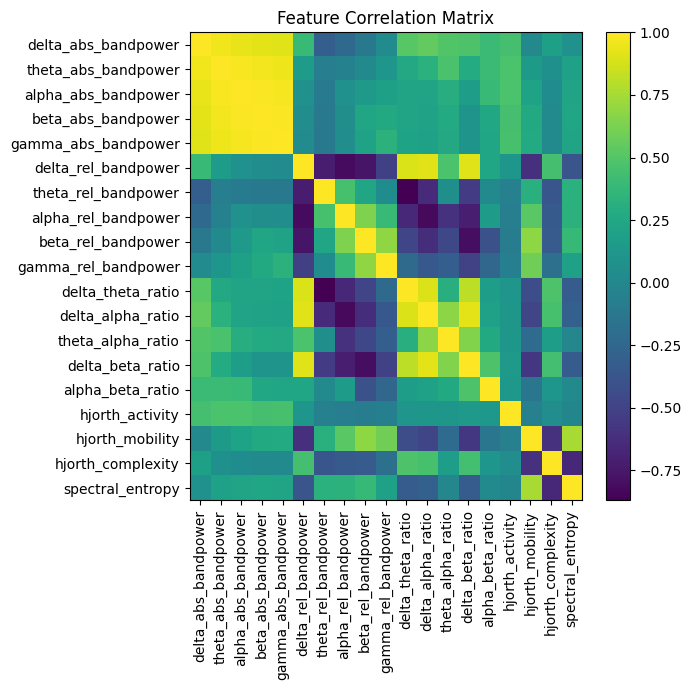

In [ ]:
# Correlation Matrix
numeric_df = feature_df.select_dtypes(include=[np.number]).copy()
cols_to_drop = [col for col in ["label", "group"] if col in numeric_df.columns]
numeric_df = numeric_df.drop(columns=cols_to_drop, errors="ignore")

# Drop rows with NaNs so correlations are not distorted
numeric_df = numeric_df.dropna()

# Compute correlation matrix
corr_matrix = numeric_df.corr(method="pearson")

# Plot
plt.figure(figsize=(7, 7))
im = plt.imshow(corr_matrix, interpolation="nearest", aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()